# Intro

In this tutorial, we apply ARGEN to the entire chromosomes and reproduce Fig. 3d,e,f,g in the manuscript.

# Arguments and set up

To run the codes, **(i)** designate the directory, where ARGEN was cloned from the Github repository, **(ii)** number of CPU cores to be used for parallel jobs, **(iii)** the significance level $\alpha$ for descendant set search and the parent set search.

In [1]:
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman", repos = "https://cloud.r-project.org")

pacman::p_load(
  here, dplyr, data.table, ggplot2, future.apply, sandwich, lmtest,hexbin
)

DIR <- here::here()   # resolves to the repo root automatically
ncores=5
alpha_desc=alpha_IV = 0.05

Set up options and directories to run the codes.

# Load functions

In [2]:
source(paste0(DIR,'/code/function/Proxy_IV_functions_parallel.R'))
source(paste0(DIR,'/code/function/inspre.R'))
Rcpp::sourceCpp(paste0(DIR,'/code/function/inspre_cpp.cpp'))

# Run ARGEN across chromosomes

In [3]:
options(future.globals.maxSize = 10 * 1024^3) 

chrlist=paste0('chr',c(1:22,"X"))

for(chr in 1:23){
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
if (!dir.exists(DAG_DIR)) dir.create(DAG_DIR, recursive = TRUE, showWarnings = FALSE)    
    

# Load and prepare for the data
## Load data from the data directory. **X_raw** contains the UMI count across cells and genes and **meta_data** contains cell specific feature information.    
X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))

nodes <- colnames(X_raw) # Node (gene) set.
p <- length(nodes) # dimension of X_raw.
perturbation_unique <- unique(meta_data$gene_id) # Perturbation set: Gene set+non targeting guides.
meta_data$gene_id <- factor(meta_data$gene_id,levels = unique(meta_data$gene_id)) 
meta_data$gem_group<-factor(meta_data$gem_group) # making sure GEM group is a factor.

C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum) # Library size estimation.    
    
## Prepare for the binary perturbation indicator matrix **D**, which is of the same dimension as **X_raw** matrix.    
D <- model.matrix(~ gene_id - 1, data = meta_data)
colnames(D) <- sub("^gene_id", "", colnames(D))
D <- D[, -c(length(perturbation_unique))]
control_ind <- which(rowSums(D) == 0)    
    

# Descendant set search

cat(paste0('Running codes for ',chrlist[chr],'\n'))
cat(paste0('Estimating Ancestors and Descendants...','\n'))
  
ds_out <- build_descendants_cov_adjust(
    X_raw = X_raw,
    D = D, 
    control_ind = control_ind,
    alpha_desc = alpha_desc, nodes = nodes,
    padj_method = "BH",
    cc_cols=c('mitopercent'),
    cc_df=meta_data %>% as.data.frame,depth=C,
    ncores = ncores, engine = "multisession"
  )

# saving the descendant sets estimated.

setwd(DAG_DIR)
saveRDS(ds_out,'ds_out_covadjust.rds')
    
# Parent set and causal DAG search    
cat(paste0('Estimating Parents...','\n'))
dag_obj <- dag_search_perturbseq(
    desc_sets = ds_out$descendant_set_score_closure,
    data_raw  = X_raw ,
    D = D ,depth =C,family = 'poisson',cc_df=data.frame(meta_data),
    cc_cols = c('mitopercent'),alpha_parent=alpha_IV,
    padj_method_parent='onlineBH',
    cores = ncores
  )

cat(paste0(chrlist[chr],' complete!','\n'))    

    
# Saving the DAG learned from ARGEN
    
edges_k <- edges_from_dagsearch(dag_obj)
maps_k  <- compute_ancestors_map(nodes, edges_k)
dag_artifact <- list(
    dag_object    = dag_obj,
    dag_edges     = edges_k,
    parents_map   = maps_k$parents_map,
    ancestors_map = maps_k$ancestors_map
)
  
setwd(DAG_DIR)  
saveRDS(dag_artifact, file = file.path(DAG_DIR,  'dag_0.05BH_0.05onlineBH.rds'))
    
    
    
}

# Reproducing main results

## Coefficient sign match across chromosomes

First, we load the DAG estimate learned from **ARGEN** and rename the genes using their corresponding standard gene symbols based on ENSG identifiers.

In [16]:
meta_data_allchr <- fread(paste0(DIR,'/data/auxiliary/meta_data_allchr.csv'))
id2name <- meta_data_allchr %>%
  distinct(gene_id, gene) %>%
  mutate(across(everything(), as.character))


chrlist=paste0('chr',c(1:22,"X"))
true_edges=c()
all_edges=c()
for(chr in c(1:23)){
chrlist=paste0('chr',c(1:22,"X"))
DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
setwd(DAG_DIR)
dag_artifact=readRDS(file = 'dag_0.05BH_0.05onlineBH.rds')
true_edges=rbind(true_edges,data.frame(chr=chrlist[chr],dag_artifact$dag_edges))
all_edges=rbind(all_edges,data.frame(chr=chrlist[chr],do.call('rbind',dag_artifact$dag_object$edge_structure_all)))
    }


true_edges_name=  true_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    rename(to_gene = gene)


all_edges_name=all_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    rename(to_gene = gene)


Next, obtain the intervention effects of perturbing parent genes on their child genes. Then, compare the signs of these intervention effects with those of the corresponding edge coefficients.

In [17]:
plan(multicore, workers = ncores)# adjust the core number based on availability.

blas_threads=1
if (blas_threads == 1) {
    Sys.setenv(
      OMP_NUM_THREADS = "1", OPENBLAS_NUM_THREADS = "1",
      MKL_NUM_THREADS = "1", VECLIB_MAXIMUM_THREADS = "1",
      BLIS_NUM_THREADS = "1", GOTO_NUM_THREADS = "1"
    )
    if (requireNamespace("RhpcBLASctl", quietly = TRUE)) {
      RhpcBLASctl::blas_set_num_threads(1)
      RhpcBLASctl::omp_set_num_threads(1)
    }
    if (requireNamespace("data.table", quietly = TRUE)) {
      data.table::setDTthreads(1)
    }
  }
    
    


   
chrlist <- paste0('chr', c(1:22, "X"))


process_chr <- function(chr) {


  
    X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
    meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))
  # Design for perturbations
  perturbation_unique <- unique(meta_data$gene_id)
  meta_data$gene_id <- factor(meta_data$gene_id,
                                            levels = unique(meta_data$gene_id))
  meta_data$gem_group <- as.factor(meta_data$gem_group)

  D <- model.matrix(~ gene_id - 1, data = meta_data)
  colnames(D) <- sub("^gene_id", "", colnames(D))
  D <- D[, -c(length(perturbation_unique))] 
  control_ind <- which(rowSums(D) == 0)

  # Offset vector (depth)
  C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)

  # Covariates (use model.matrix to expand factors robustly)
  cc_cols <- c('mitopercent')
  cc_df <- as.data.frame(meta_data %>% dplyr::select(cc_cols))
  # build a model matrix with intercept; will create gem_group dummies
  X_cc_all <- model.matrix(~ ., data = cc_df)

  chrom <- chrlist[chr]
  df <- true_edges_name %>% dplyr::filter(chr == chrom)

  if (nrow(df) == 0L) {
    return(data.table(beta = NA_real_, pval = NA_real_, chr = chrom)[0])
  }

  # --------- parallel over i (rows of df) ----------
  res_list_i <- future_lapply(
    seq_len(nrow(df)),
    function(i) {
      fg <- df$from_gene[i]
      tg <- df$to_gene[i]


      fg_id <- unique(meta_data$gene_id[meta_data$gene == fg])
      tg_id <- unique(meta_data$gene_id[meta_data$gene == tg])

      if (length(fg_id) != 1L || length(tg_id) != 1L) {
        return(data.frame(beta = NA_real_, pval = NA_real_, from = fg, to = tg))
      }

      perturb_ind <- D[, fg_id] == 1
      if (!any(perturb_ind) || length(control_ind) == 0L) {
        return(data.frame(beta = NA_real_, pval = NA_real_, from = fg, to = tg))
      }

      # response and treatment
      x1 <- X_raw[perturb_ind, tg_id]
      x0 <- X_raw[control_ind, tg_id]
      y  <- c(x1, x0)
      d  <- c(D[perturb_ind, fg_id], D[control_ind, fg_id])

      # covariate rows aligned to perturb/control
      Xc <- rbind(X_cc_all[perturb_ind, , drop = FALSE],
                  X_cc_all[control_ind, , drop = FALSE])

      depth <- c(C[perturb_ind], C[control_ind])

      # build data and fit
      tmpdat <- data.frame(y = y, d = d, Xc, check.names = TRUE)
      fml <- stats::as.formula(
        paste0("y ~ d + ",
               paste(setdiff(colnames(Xc), "(Intercept)"), collapse = " + "))
      )

      glmres <- glm(fml, offset = log(pmax(depth, 1e-12)),
                    data = tmpdat, family = poisson())

      beta <- coef(glmres)['d']

      data.frame(beta = beta, from = fg, to = tg, stringsAsFactors = FALSE)
    },
    future.seed = TRUE
  )

  res_chr <- data.table::rbindlist(res_list_i, use.names = TRUE, fill = TRUE)
  res_chr[, chr := chrom]
  res_chr
}


res_list_chr <- lapply(1:23, process_chr)
res_allchr   <- data.table::rbindlist(res_list_chr, use.names = TRUE, fill = TRUE)

df_allchr=true_edges_name%>% mutate(intervention_coef=res_allchr$beta)
saveRDS(df_allchr,paste0(DIR,'/results/application/chr_specific/sanity_check_coef.rds'))

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(cc_cols)

  # Now:
  data %>% select(all_of(cc_cols))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


Visualize the comparison between the edge coefficients and the intervention effects. The figure below reproduces Fig 3d of the manuscript.

### Read in the intervention effect result

In [18]:
df_allchr=readRDS(paste0(DIR,'/results/application/chr_specific/sanity_check_coef.rds'))

# Fig 3d

Warning message:
“Removed 8 rows containing non-finite outside the scale range (`stat_binhex()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 8 rows containing non-finite outside the scale range (`stat_smooth()`).”


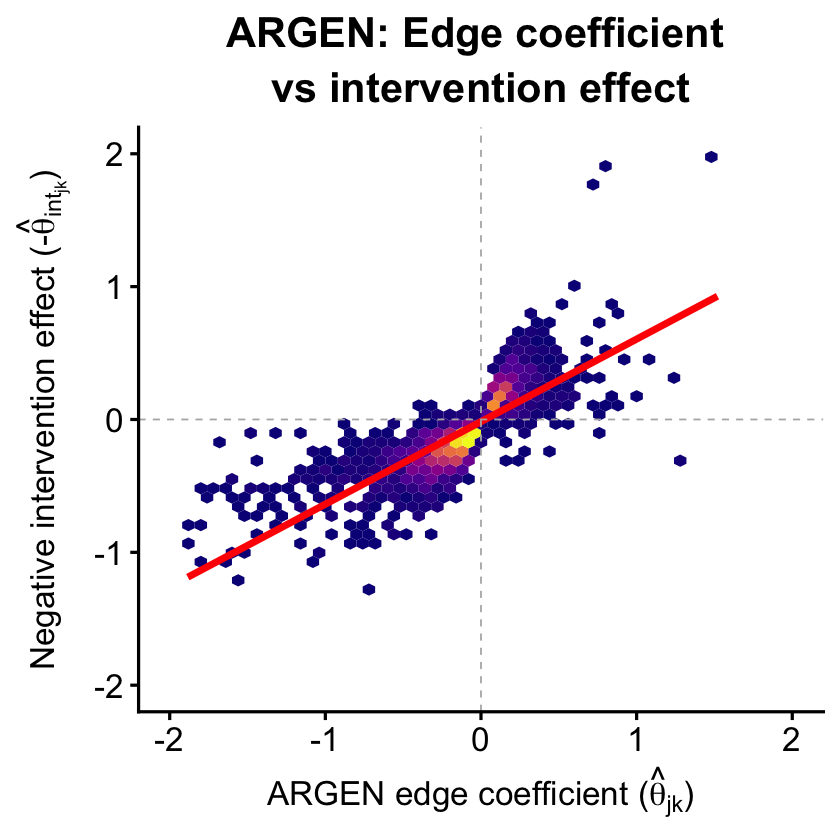

In [19]:
ggplot(df_allchr, aes(x = coef, y = -intervention_coef)) +
  # Using geom_hex to handle density, show.legend = FALSE to remove the scale bar
  geom_hex(bins = 50, show.legend = FALSE) + 
  
  # Viridis 'plasma' palette (high contrast)
  scale_fill_viridis_c(option = "plasma") +
  
  geom_smooth(method = "lm", lwd = 2, lty = 1, col = 'red', se = FALSE) +
  labs(
    y = expression("Negative intervention effect (-" * hat(theta)[int[jk]] * ")"),
    x =  expression("ARGEN edge coefficient (" * hat(theta)[jk] * ")"),
    title = "ARGEN: Edge coefficient \nvs intervention effect"
  ) +
  theme_classic(base_size = 20) +
  theme(
    # Increased size to 30 and adjusted line height (vjust/lineheight)
    plot.title = element_text(hjust = 0.5, face = "bold", size = 25, lineheight = 1.1),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 20)
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray70", linewidth = 0.5) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray70", linewidth = 0.5) +ylim(-2,2)+xlim(-2,2)

## Coefficient sign match across chromosomes (reversed order)

Now, obtain the (reversed) intervention effects of perturbing children genes on their parent genes. Then, compare the signs of these intervention effects with those of the corresponding edge coefficients.

In [20]:
# Per-chromosome worker: parallelize the inner i-loop
process_chr <- function(chr) {

    X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
    meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))
  
  # Design for perturbations
  perturbation_unique <- unique(meta_data$gene_id)
  meta_data$gene_id <- factor(meta_data$gene_id,
                                            levels = unique(meta_data$gene_id))
  meta_data$gem_group <- as.factor(meta_data$gem_group)
  
  D <- model.matrix(~ gene_id - 1, data = meta_data)
  colnames(D) <- sub("^gene_id", "", colnames(D))
  D <- D[, -c(length(perturbation_unique))] 
  control_ind <- which(rowSums(D) == 0)
  
  # Offset vector (depth)
  C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)
  

  cc_cols <- c('mitopercent')
  cc_df <- as.data.frame(meta_data %>% dplyr::select(cc_cols))
  # build a model matrix with intercept; will create gem_group dummies
  X_cc_all <- model.matrix(~ ., data = cc_df)
  
  chrom <- chrlist[chr]
  df <- true_edges_name %>% dplyr::filter(chr == chrom)
  
  if (nrow(df) == 0L) {
    return(data.table(beta = NA_real_, pval = NA_real_, chr = chrom)[0])  # empty
  }
  
  # --------- parallel over i (rows of df) ----------
  res_list_i <- future_lapply(
    seq_len(nrow(df)),
    function(i) {
      fg <- df[i, ]$to_gene
      tg <- df[i, ]$from_gene
      

      fg_id <- unique(meta_data$gene_id[meta_data$gene == fg])
      tg_id <- unique(meta_data$gene_id[meta_data$gene == tg])
      
      if (length(fg_id) != 1L || length(tg_id) != 1L) {
        return(data.frame(beta = NA_real_, pval = NA_real_, from = fg, to = tg))
      }
      
      perturb_ind <- D[, fg_id] == 1
      if (!any(perturb_ind) || length(control_ind) == 0L) {
        return(data.frame(beta = NA_real_, pval = NA_real_, from = fg, to = tg))
      }
      
      # response and treatment
      x1 <- X_raw[perturb_ind, tg_id]
      x0 <- X_raw[control_ind, tg_id]
      y  <- c(x1, x0)
      d  <- c(D[perturb_ind, fg_id], D[control_ind, fg_id])
      
      # covariate rows aligned to perturb/control
      Xc <- rbind(X_cc_all[perturb_ind, , drop = FALSE],
                  X_cc_all[control_ind, , drop = FALSE])
      
      depth <- c(C[perturb_ind], C[control_ind])
      
      # build data and fit
      tmpdat <- data.frame(y = y, d = d, Xc, check.names = TRUE)
      fml <- stats::as.formula(
        paste0("y ~ d + ",
               paste(setdiff(colnames(Xc), "(Intercept)"), collapse = " + "))
      )
      
      glmres <- glm(fml, offset = log(pmax(depth, 1e-12)),
                    data = tmpdat, family = poisson())
      
      test  <- lmtest::coeftest(glmres, vcov = sandwich::vcovHC(glmres, type = "HC0"))

      if ("d" %in% rownames(test)) {
        beta <- unname(test["d", 1])
        pval <- unname(test["d", 4])
      } else {

        beta <- unname(test[2, 1])
        pval <- unname(test[2, 4])
      }
      
      data.frame(beta = beta, pval = pval, from = fg, to = tg, stringsAsFactors = FALSE)
    },
    future.seed = TRUE
  )
  
  res_chr <- data.table::rbindlist(res_list_i, use.names = TRUE, fill = TRUE)
  res_chr[, chr := chrom]
  res_chr
}


res_list_chr <- lapply(1:23, process_chr)  # <- sequential here
res_allchr   <- data.table::rbindlist(res_list_chr, use.names = TRUE, fill = TRUE)

df_allchr_reversed=true_edges_name%>% mutate(intervention_coef=res_allchr$beta,intervention_p=res_allchr$pval)
saveRDS(df_allchr_reversed,paste0(DIR,'/results/application/chr_specific/sanity_check_coef_reversed.rds'))

Visualize the comparison between the edge coefficients and the intervention effects. The figure below reproduces Fig 3e of the manuscript.

### Read in the reversed intervention effect result

In [21]:
df_allchr_reversed=readRDS(paste0(DIR,'/results/application/chr_specific/sanity_check_coef_reversed.rds'))

# Fig 3e

Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_binhex()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”


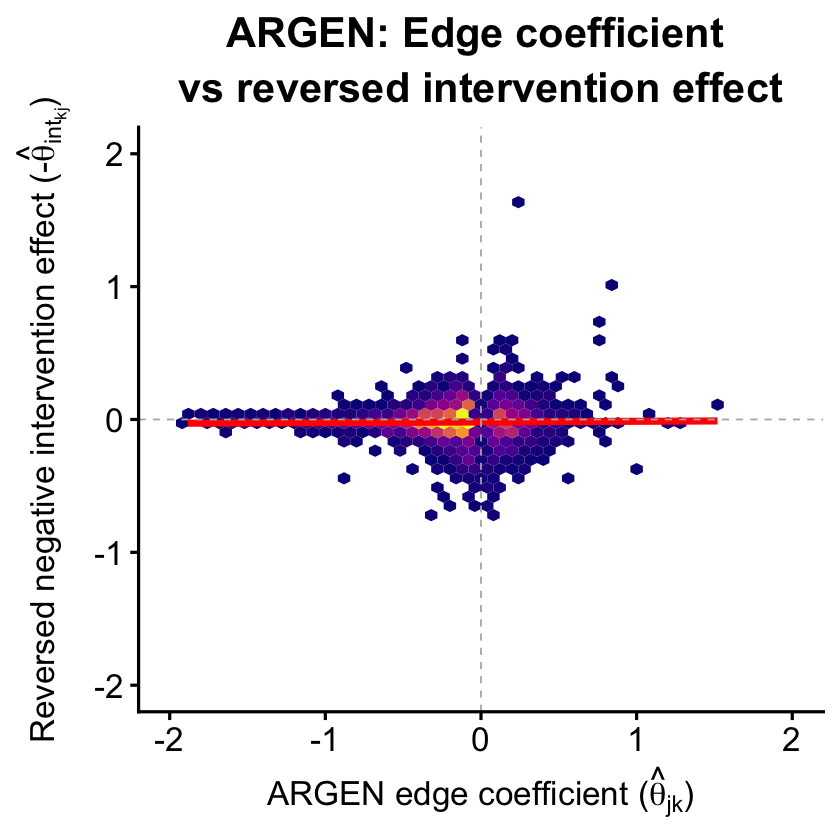

In [22]:
ggplot(df_allchr_reversed, aes(x = coef, y = -intervention_coef)) +
  # Using geom_hex to handle density, show.legend = FALSE to remove the scale bar
  geom_hex(bins = 50, show.legend = FALSE) + 
  
  # Viridis 'plasma' palette (high contrast)
  scale_fill_viridis_c(option = "plasma")+
  
  # Regression line
  geom_smooth(method = "lm", lwd = 2, lty = 1, col = 'red', se = FALSE)+
  labs(
    y = expression("Reversed negative intervention effect (-" * hat(theta)[int[kj]] * ")"),
    x =  expression("ARGEN edge coefficient (" * hat(theta)[jk] * ")"),
    title = "ARGEN: Edge coefficient \nvs reversed intervention effect"
  ) +
  theme_classic(base_size = 20) +
  theme(
    # Increased size to 30 and adjusted line height (vjust/lineheight)
    plot.title = element_text(hjust = 0.5, face = "bold", size = 25, lineheight = 1.1),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 20)
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray70", linewidth = 0.5) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray70", linewidth = 0.5) +ylim(-2,2)+xlim(-2,2)

# INSPRE implementation

In [ ]:
chrlist=paste0('chr',c(1:22,"X"))
for(chr in c(1:12,14:23)){# chr13 gives error.
  print(chr)    
  set.seed(1)#might need seed, as INSPRE requires CV.
  
  # -------------------------------
  # Paths / output
  # -------------------------------
  DAG_DIR <- paste0(DIR,'/results/application/chr_specific/',chrlist[chr])
  
  if (!dir.exists(DAG_DIR)) {
    dir.create(DAG_DIR, recursive = TRUE)
  }
  
  # -------------------------------
  # Load data (your paths)
  # -------------------------------
  
  X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
  meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))
  
  # Design matrix D (exactly as you had)
  perturbation_unique <- unique(meta_data$gene_id)
  meta_data$gene_id <- factor(meta_data$gene_id,
                                            levels = unique(meta_data$gene_id))
  meta_data$gem_group<-factor(meta_data$gem_group)
  
  D <- model.matrix(~ gene_id - 1, data = meta_data)
  colnames(D) <- sub("^gene_id", "", colnames(D))
  D <- D[, -c(length(perturbation_unique))]  # keep your exclusion
  control_ind <- which(rowSums(D) == 0)
  
  # Offset vector (depth)
  C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)
  
  
  # Basic checks
  nodes <- colnames(X_raw)
  p <- length(nodes)
  cc_cols=c('mitopercent')
  XA     <- log(sweep(X_raw, 1, C, "/") + 1e-3) %>% as.matrix
  cc_df=data.frame(meta_data)[,cc_cols,drop=FALSE]
  L <- model.matrix(~ mitopercent, data = cc_df)
  
  normX  <- resid(lm(XA ~ L))
  
  colnames(normX) <- nodes
  
  targets=meta_data$gene_id %>% as.character
  targets[targets=="non-targeting"]="control"
  targets=as.factor(targets)
  
  inspre_res <- fit_inspre_from_X(normX, targets,constraint = "VU", verbose = 0,DAG = TRUE,cv_folds = 5,nlambda = 10,max_med_ratio = 50,min_nz = 0.03/2) 
  
  saveRDS(inspre_res, file = file.path(DAG_DIR,  'inspre_res.rds'))    
  
  best_k     <- which.min(inspre_res$eps_hat_G)
  G_hat_full <- inspre_res$G_hat[ , , best_k]
  
  result_INSPRE <- result_from_ghat(G_hat_full, nodes, tol = 1e-8)
  
  saveRDS(result_INSPRE, file = file.path(DAG_DIR,  'result_INSPRE.rds'))    
  
  
  
  print(paste0(chr," complete!"))        
}

[1] 1
[1] "Local inspre function is called"
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
[1] "Local inspre function is called"
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
L is inceasing, breaking and returning last U, V.
[1] "Local inspre function is called"
L is inceasing, breaking and r

## Coefficient sign match across chromosomes for INSPRE

In [24]:
meta_data_allchr <- fread(paste0(DIR,'/data/auxiliary/meta_data_allchr.csv'))
id2name <- meta_data_allchr %>%
  distinct(gene_id, gene) %>%
  mutate(across(everything(), as.character))

chrlist=paste0('chr',c(1:22,"X"))
true_edges=c()
all_edges=c()
for(chr in c(1:12,14:18,20,22:23)){
chrlist=paste0('chr',c(1:22,"X"))
DAG_DIR <- paste0(DIR,"/results/application/chr_specific/",chrlist[chr])
setwd(DAG_DIR)

result_INSPRE=readRDS(file = file.path(DAG_DIR,  'result_INSPRE.rds'))    
    
    
true_edges=rbind(true_edges,data.frame(chr=chrlist[chr],result_INSPRE$edge_structure))
all_edges=rbind(all_edges,data.frame(chr=chrlist[chr],do.call('rbind',result_INSPRE$edge_structure_all)))
    }

true_edges_name=  true_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    rename(to_gene = gene)


all_edges_name=all_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    rename(to_gene = gene)

In [25]:
blas_threads=1
if (blas_threads == 1) {
    Sys.setenv(
      OMP_NUM_THREADS = "1", OPENBLAS_NUM_THREADS = "1",
      MKL_NUM_THREADS = "1", VECLIB_MAXIMUM_THREADS = "1",
      BLIS_NUM_THREADS = "1", GOTO_NUM_THREADS = "1"
    )
    if (requireNamespace("RhpcBLASctl", quietly = TRUE)) {
      RhpcBLASctl::blas_set_num_threads(1)
      RhpcBLASctl::omp_set_num_threads(1)
    }
    if (requireNamespace("data.table", quietly = TRUE)) {
      data.table::setDTthreads(1)
    }
  }
    
    

In [26]:
# --- NEW: parallel over i, not chr ---


plan(multicore, workers = ncores)   # or: plan(multisession, workers = 40) on macOS/Windows

chrlist <- paste0('chr', c(1:22, "X"))

# Per-chromosome worker: parallelize the inner i-loop
process_chr <- function(chr) {
  
  # -------------------------------
  # Load data (your paths)
  # -------------------------------
  X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
  meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))
  
  # Design for perturbations
  perturbation_unique <- unique(meta_data$gene_id)
  meta_data$gene_id <- factor(meta_data$gene_id,
                                            levels = unique(meta_data$gene_id))
  meta_data$gem_group <- as.factor(meta_data$gem_group)
  
  D <- model.matrix(~ gene_id - 1, data = meta_data)
  colnames(D) <- sub("^gene_id", "", colnames(D))
  D <- D[, -c(length(perturbation_unique))]  # keep your exclusion
  control_ind <- which(rowSums(D) == 0)
  
  # Offset vector (depth)
  C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)
  
  # Covariates (use model.matrix to expand factors robustly)
  cc_cols <- c('mitopercent')
  cc_df <- as.data.frame(meta_data %>% dplyr::select(all_of(cc_cols)))
  
  # build a model matrix with intercept; will create gem_group dummies
  X_cc_all <- model.matrix(~ ., data = cc_df)
  
  chrom <- chrlist[chr]
  df <- true_edges_name %>% dplyr::filter(chr == chrom)
  
  if (nrow(df) == 0L) {
    # Include zscore in the empty data.table to ensure rbindlist matches structures
    return(data.table(beta = NA_real_, zscore = NA_real_, pval = NA_real_, chr = chrom)[0]) 
  }
  
  # --------- parallel over i (rows of df) ----------
  res_list_i <- future_lapply(
    seq_len(nrow(df)),
    function(i) {
      fg <- df$from_gene[i]
      tg <- df$to_gene[i]
      
      # index columns by gene_id strings
      fg_id <- unique(meta_data$gene_id[meta_data$gene == fg])
      tg_id <- unique(meta_data$gene_id[meta_data$gene == tg])
      
      if (length(fg_id) != 1L || length(tg_id) != 1L) {
        return(data.frame(beta = NA_real_, zscore = NA_real_, from = fg, to = tg))
      }
      
      perturb_ind <- D[, fg_id] == 1
      if (!any(perturb_ind) || length(control_ind) == 0L) {
        return(data.frame(beta = NA_real_, zscore = NA_real_, from = fg, to = tg))
      }
      
      # response and treatment
      x1 <- X_raw[perturb_ind, tg_id]
      x0 <- X_raw[control_ind, tg_id]
      y  <- c(x1, x0)
      d  <- c(D[perturb_ind, fg_id], D[control_ind, fg_id])
      
      # covariate rows aligned to perturb/control
      Xc <- rbind(X_cc_all[perturb_ind, , drop = FALSE],
                  X_cc_all[control_ind, , drop = FALSE])
      
      depth <- c(C[perturb_ind], C[control_ind])
      
      # build data and fit
      tmpdat <- data.frame(y = y, d = d, Xc, check.names = TRUE)
      fml <- stats::as.formula(
        paste0("y ~ d + ",
               paste(setdiff(colnames(Xc), "(Intercept)"), collapse = " + "))
      )
      
      # Wrap in try() to handle non-converging models gracefully
      glmres <- try(glm(fml, offset = log(pmax(depth, 1e-12)),
                        data = tmpdat, family = poisson()), silent = TRUE)
      
      if (inherits(glmres, "try-error")) {
        return(data.frame(beta = NA_real_, zscore = NA_real_, from = fg, to = tg))
      }
      
      # Extract coefficients and z-scores
      sum_mat <- summary(glmres)$coefficients
      
      if ("d" %in% rownames(sum_mat)) {
        beta   <- sum_mat["d", "Estimate"]
        zscore <- sum_mat["d", "z value"]
      } else {
        beta   <- NA_real_
        zscore <- NA_real_
      }
      
      data.frame(beta = beta, zscore = zscore, from = fg, to = tg, stringsAsFactors = FALSE)
    },
    future.seed = TRUE
  )
  
  res_chr <- data.table::rbindlist(res_list_i, use.names = TRUE, fill = TRUE)
  res_chr[, chr := chrom]
  res_chr
}

# ---- outer: sequential over chromosomes; inner: parallel over i ----
res_list_chr <- lapply(1:23, process_chr)  # <- sequential here
res_allchr   <- data.table::rbindlist(res_list_chr, use.names = TRUE, fill = TRUE)

# (Optional) back to sequential for any further futures you might run later
plan(sequential)

#df_allchr=true_edges_name%>% mutate(intervention_coef=res_allchr[,1],intervention_p=res_allchr[,2])
df_allchr=true_edges_name%>% mutate(intervention_coef=res_allchr$beta,intervention_zscore=res_allchr$zscore)
saveRDS(df_allchr,paste0(DIR,'/results/application/chr_specific/sanity_check_coef_INSPRE.rds'))

### Read in intervention effect for the INSPRE

In [27]:
df_allchr=readRDS(paste0(DIR,'/results/application/chr_specific/sanity_check_coef_INSPRE.rds'))

# Fig 3f

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_binhex()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”


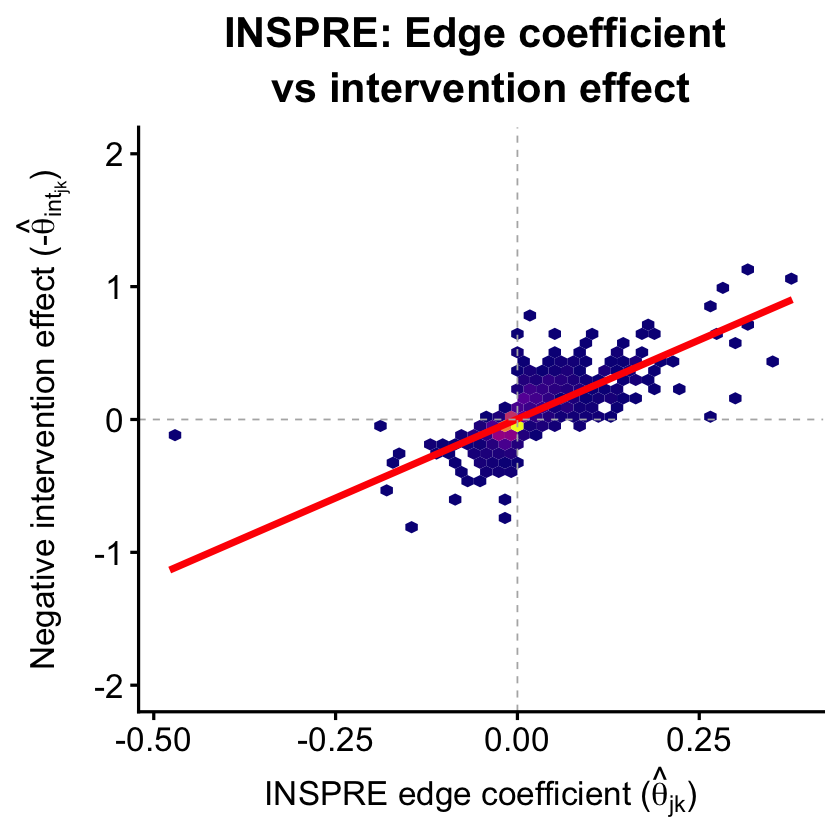

In [28]:


ggplot(df_allchr, aes(x = coef, y = -intervention_coef)) +
  # Using geom_hex to handle density, show.legend = FALSE to remove the scale bar
  geom_hex(bins = 50, show.legend = FALSE) + 
  
  # Viridis 'plasma' palette (high contrast)
  scale_fill_viridis_c(option = "plasma") +
  
  geom_smooth(method = "lm", lwd = 2, lty = 1, col = 'red', se = FALSE) +
  labs(
    y = expression("Negative intervention effect (-" * hat(theta)[int[jk]] * ")"),
    x =  expression("INSPRE edge coefficient (" * hat(theta)[jk] * ")"),
    title = "INSPRE: Edge coefficient \nvs intervention effect"
  ) +
  theme_classic(base_size = 20) +
  theme(
    # Increased size to 30 and adjusted line height (vjust/lineheight)
    plot.title = element_text(hjust = 0.5, face = "bold", size = 25, lineheight = 1.1),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 20)
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray70", linewidth = 0.5) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray70", linewidth = 0.5)  +ylim(-2,2)

# Fig 3g

## Coefficient sign match across chromosomes for INSPRE (reversed order)

In [29]:
# --- NEW: parallel over i, not chr ---


plan(multicore, workers = ncores)   # or: plan(multisession, workers = 40) on macOS/Windows

chrlist <- paste0('chr', c(1:22, "X"))

# Per-chromosome worker: parallelize the inner i-loop
process_chr <- function(chr) {
  
  
  # -------------------------------
  # Load data (your paths)
  # -------------------------------
  X_raw  <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/X_raw_",chrlist[chr],'.rds'))
  meta_data <- readRDS(paste0(DIR,'/data/chr_specific/',chrlist[chr],"/meta_data_",chrlist[chr],'.rds'))
  
  # Design for perturbations
  perturbation_unique <- unique(meta_data$gene_id)
  meta_data$gene_id <- factor(meta_data$gene_id,
                                            levels = unique(meta_data$gene_id))
  meta_data$gem_group <- as.factor(meta_data$gem_group)
  
  D <- model.matrix(~ gene_id - 1, data = meta_data)
  colnames(D) <- sub("^gene_id", "", colnames(D))
  D <- D[, -c(length(perturbation_unique))]  # keep your exclusion
  control_ind <- which(rowSums(D) == 0)
  
  # Offset vector (depth)
  C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)
  
  # Covariates (use model.matrix to expand factors robustly)
  cc_cols <- c('mitopercent')
  cc_df <- as.data.frame(meta_data %>% dplyr::select(cc_cols))
  # build a model matrix with intercept; will create gem_group dummies
  X_cc_all <- model.matrix(~ ., data = cc_df)
  
  chrom <- chrlist[chr]
  df <- true_edges_name %>% dplyr::filter(chr == chrom)
  
  if (nrow(df) == 0L) {
    return(data.table(beta = NA_real_, pval = NA_real_, chr = chrom)[0])  # empty
  }
  
  # --------- parallel over i (rows of df) ----------
  res_list_i <- future_lapply(
    seq_len(nrow(df)),
    function(i) {
      #fg <- df$from_gene[i]
      #tg <- df$to_gene[i]
      fg <- df[i, ]$to_gene
      tg <- df[i, ]$from_gene
      
      # index columns by gene_id strings
      fg_id <- unique(meta_data$gene_id[meta_data$gene == fg])
      tg_id <- unique(meta_data$gene_id[meta_data$gene == tg])
      
      if (length(fg_id) != 1L || length(tg_id) != 1L) {
        return(data.frame(beta = NA_real_, pval = NA_real_, from = fg, to = tg))
      }
      
      perturb_ind <- D[, fg_id] == 1
      if (!any(perturb_ind) || length(control_ind) == 0L) {
        return(data.frame(beta = NA_real_, pval = NA_real_, from = fg, to = tg))
      }
      
      # response and treatment
      x1 <- X_raw[perturb_ind, tg_id]
      x0 <- X_raw[control_ind, tg_id]
      y  <- c(x1, x0)
      d  <- c(D[perturb_ind, fg_id], D[control_ind, fg_id])
      
      # covariate rows aligned to perturb/control
      Xc <- rbind(X_cc_all[perturb_ind, , drop = FALSE],
                  X_cc_all[control_ind, , drop = FALSE])
      
      depth <- c(C[perturb_ind], C[control_ind])
      
      # build data and fit
      tmpdat <- data.frame(y = y, d = d, Xc, check.names = TRUE)
      fml <- stats::as.formula(
        paste0("y ~ d + ",
               paste(setdiff(colnames(Xc), "(Intercept)"), collapse = " + "))
      )
      
      glmres <- try(glm(fml, offset = log(pmax(depth, 1e-12)),
                        data = tmpdat, family = poisson()), silent = TRUE)
      
      if (inherits(glmres, "try-error")) {
        return(data.frame(beta = NA_real_, zscore = NA_real_, from = fg, to = tg))
      }
      
      # Extract coefficients and z-scores
      sum_mat <- summary(glmres)$coefficients
      
      if ("d" %in% rownames(sum_mat)) {
        beta   <- sum_mat["d", "Estimate"]
        zscore <- sum_mat["d", "z value"]
      } else {
        beta   <- NA_real_
        zscore <- NA_real_
      }
      
      data.frame(beta = beta, zscore = zscore, from = fg, to = tg, stringsAsFactors = FALSE)
    },
    future.seed = TRUE
  )
  
  res_chr <- data.table::rbindlist(res_list_i, use.names = TRUE, fill = TRUE)
  res_chr[, chr := chrom]
  res_chr
}

# ---- outer: sequential over chromosomes; inner: parallel over i ----
res_list_chr <- lapply(1:23, process_chr)  # <- sequential here
res_allchr   <- data.table::rbindlist(res_list_chr, use.names = TRUE, fill = TRUE)

# (Optional) back to sequential for any further futures you might run later
plan(sequential)
#df_allchr=true_edges_name%>% mutate(intervention_coef=res_allchr[,1],intervention_p=res_allchr[,2])
df_allchr_reversed=true_edges_name%>% mutate(intervention_coef=res_allchr$beta,intervention_zscore=res_allchr$zscore)
saveRDS(df_allchr_reversed,paste0(DIR,'/results/application/chr_specific/sanity_check_coef_reversed_INSPRE.rds'))

### Read in reverse intervention effect for the INSPRE

In [30]:
df_allchr_reversed=readRDS(paste0(DIR,'/results/application/chr_specific/sanity_check_coef_reversed_INSPRE.rds'))

`geom_smooth()` using formula = 'y ~ x'


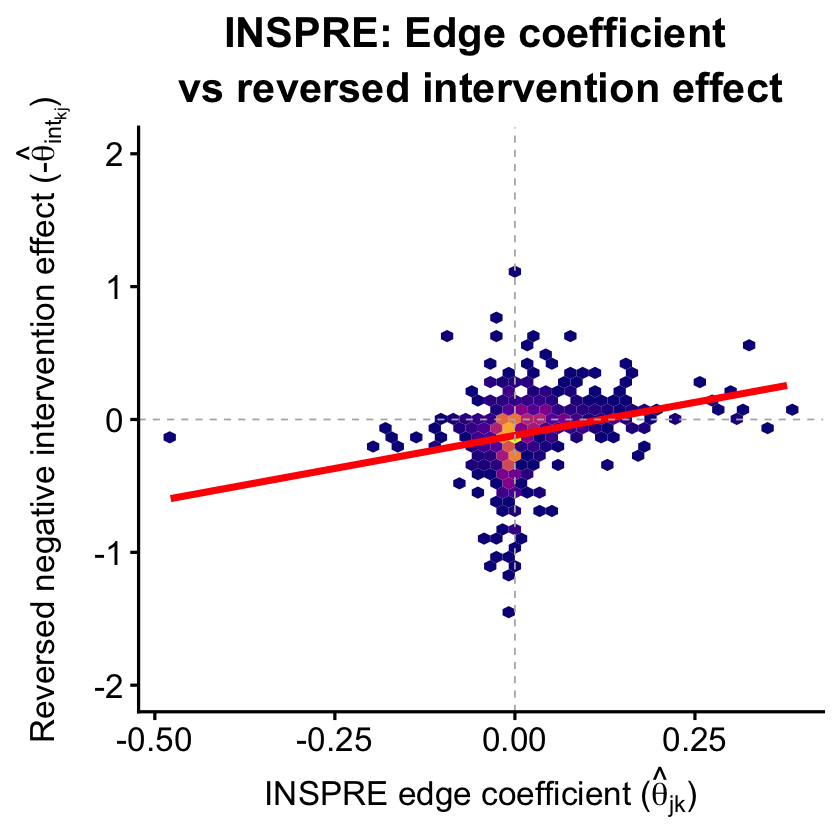

In [31]:
ggplot(df_allchr_reversed, aes(x = coef, y = -intervention_coef)) +
  # Using geom_hex to handle density, show.legend = FALSE to remove the scale bar
  geom_hex(bins = 50, show.legend = FALSE) + 
  
  # Viridis 'plasma' palette (high contrast)
  scale_fill_viridis_c(option = "plasma") +
  
  geom_smooth(method = "lm", lwd = 2, lty = 1, col = 'red', se = FALSE) +
  labs(
    y = expression("Reversed negative intervention effect (-" * hat(theta)[int[kj]] * ")"),
    x =  expression("INSPRE edge coefficient (" * hat(theta)[jk] * ")"),
    title = "INSPRE: Edge coefficient \nvs reversed intervention effect"
  ) +
  theme_classic(base_size = 20) +
  theme(
    # Increased size to 30 and adjusted line height (vjust/lineheight)
    plot.title = element_text(hjust = 0.5, face = "bold", size = 25, lineheight = 1.1),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 20)
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray70", linewidth = 0.5) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray70", linewidth = 0.5)  +ylim(-2,2)